# MODELOS BASELINE: CLASIFICACIÓN DE PATOLOGÍAS CON ML CLÁSICO

> **Pipeline integrado con RAD-ALERT:** Este notebook consume la salida del notebook de inferencia (`0_1_Inferencia_RAD_ALERT.ipynb`), es decir el archivo `rad_criticos.xlsx` que contiene únicamente los reportes clasificados como **Críticos** por el modelo RAD-ALERT. Sobre ese subconjunto se aplican las etiquetas de patología (basadas en reglas del notebook de análisis) y se entrenan los modelos tradicionales de clasificación multilabel.

**Flujo de datos:**  
`data.xlsx` → *0_Análisis y Transformación* → `data_cleaned.xlsx` → *0_1_Inferencia RAD-ALERT* → `rad_criticos.xlsx` → **1_Modelos_Exploracion (este notebook)**


In [55]:
# Importación de librerías para modelado ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

# Modelos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

# Preprocesamiento y evaluación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, precision_recall_curve,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, cohen_kappa_score
)

# Configuración
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')


## Entrenamiento con datos críticos (rad_criticos.xlsx)

**Objetivo:** Evaluar los modelos baseline (SVM, RF, LR, NB) entrenados exclusivamente sobre el subconjunto de reportes críticos sin augmentación, para establecer una línea de comparación con las estrategias LLM y ROS.

In [56]:
# =============================================================================
# CARGA Y ENTRENAMIENTO — DATOS CRÍTICOS (rad_criticos.xlsx)
# Sin augmentación — línea base para comparar con estrategias LLM y ROS.
# =============================================================================
from pathlib import Path

# DATA_DIR podría no estar definido aún (se define en la celda de carga LLM)
_posibles = [Path('../data'), Path('data'), Path.cwd()/'data', Path.cwd().parent/'data']
DATA_DIR = next((p.resolve() for p in _posibles if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('No se encontró el directorio data.')

_crit_path = DATA_DIR / 'rad_criticos.xlsx'
df_criticos = pd.read_excel(_crit_path)
for col in ['Hallazgos', 'Opinión']:
    df_criticos[col] = df_criticos[col].fillna('').astype(str)
df_criticos['texto'] = df_criticos['Hallazgos'] + ' ' + df_criticos['Opinión']

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
# Normalizar nombres de columnas para evitar errores de mayúsculas/minúsculas
_col_map = {c.lower().strip(): c for c in df_criticos.columns}
_rename_map = {_col_map[p]: p for p in patologias if p in _col_map}
df_criticos = df_criticos.rename(columns=_rename_map)

_missing = [p for p in patologias if p not in df_criticos.columns]
if _missing:
    print(f"Columnas faltantes; se generarán por reglas: {_missing}")
    _text_col = 'Hallazgos' if 'Hallazgos' in df_criticos.columns else 'texto'
    if _text_col not in df_criticos.columns:
        raise KeyError("No se encontró una columna de texto para generar etiquetas.")

    KEYWORDS_NEGATIVOS_GLOBAL = [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'ya descrito','ya visualizado','sin cambios','estable','resolucion','resolución'
    ]
    NEGACIONES_CONTEXTUALES = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de','negativo para',
        'negativa para'
    ]
    def detectar_patologia_robusta(texto, keywords_pos, keywords_neg=None):
        if not isinstance(texto, str):
            return 0
        texto = texto.lower()
        keywords_neg = keywords_neg or KEYWORDS_NEGATIVOS_GLOBAL
        kw_ord = sorted(keywords_pos, key=len, reverse=True)
        oraciones = re.split(r'[.;]', texto)
        for oracion in oraciones:
            oracion = oracion.strip()
            kw_encontrada = next((kw for kw in kw_ord if kw in oracion), None)
            if not kw_encontrada:
                continue
            if re.search(re.escape(kw_encontrada) + r'\s*:\s*no\b', oracion):
                continue
            if re.search(re.escape(kw_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
                continue
            idx_kw = oracion.find(kw_encontrada)
            segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
            if any(neg in segmento_previo for neg in NEGACIONES_CONTEXTUALES):
                continue
            if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(kw_encontrada), oracion):
                continue
            if any(ant in oracion for ant in keywords_neg):
                continue
            if 'sin cambios' in oracion and kw_encontrada in oracion:
                continue
            return 1
        return 0

    KW_HEMORRAGIA = [
        'hemorragia subaracnoidea','hematoma subdural','hematoma epidural',
        'sangrado intraparenquimatoso','sangrado intraventricular',
        'hemorragia intraparenquimatosa','hemorragia intraventricular',
        'foco hemorragico','focos hemorragicos','hemorragia','hematoma','sangrado',
    ]
    KW_ACV = [
        'infarto cerebral','infarto lacunar','infartos lacunares',
        'evento isquemico','evento cerebrovascular','area de isquemia',
        'hipodensidad cortical','hipodensidad subcortical',
        'infarto','isquemia','isquemico','isquemica','ictus','acv',
    ]
    KW_FRACTURA = [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo',
    ]
    KW_DLM = [
        'desviacion de la linea media','desviacion linea media',
        'linea media desplazada','desplazamiento de la linea media',
        'shift de linea media','herniacion subfalcina','hernia subfalcina',
    ]
    df_criticos['hemorragia'] = df_criticos[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_HEMORRAGIA))
    df_criticos['acv'] = df_criticos[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_ACV))
    df_criticos['fractura_compleja_craneo'] = df_criticos[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_FRACTURA))
    df_criticos['desviacion_linea_media'] = df_criticos[_text_col].apply(
        lambda x: detectar_patologia_robusta(x, KW_DLM))

    _missing = [p for p in patologias if p not in df_criticos.columns]
    if _missing:
        raise KeyError(f"Faltan columnas de patología en rad_criticos.xlsx: {_missing}")

_stratify_col = df_criticos['hemorragia'] if 'hemorragia' in df_criticos.columns else None
if _stratify_col is not None and _stratify_col.nunique() < 2:
    print("Aviso: 'hemorragia' no tiene suficientes clases para estratificar; se desactiva.")
    _stratify_col = None

df_crit_train, df_crit_test = train_test_split(
    df_criticos, test_size=0.2, random_state=42,
    stratify=_stratify_col)

print(f'Críticos — Train: {len(df_crit_train)} | Test: {len(df_crit_test)}')
for p in patologias:
    n_tr = int(df_crit_train[p].sum())
    n_te = int(df_crit_test[p].sum())
    print(f'  {p:<35}  Train+: {n_tr:3d} ({100*n_tr/len(df_crit_train):5.1f}%)  Test+: {n_te:2d}')

_stopwords = ['de','la','y','el','en','del','con','se','las','los','por','para',
              'al','lo','un','una','es','su','sus','que','a','o','sin','no',
              'izquierdo','izquierda','derecha','derecho','mm']

_vec_crit = TfidfVectorizer(max_features=200, min_df=3, max_df=0.9,
                            ngram_range=(1, 2), stop_words=_stopwords)
_X_crit_tr = _vec_crit.fit_transform(df_crit_train['texto'].astype(str))
_X_crit_te = _vec_crit.transform(df_crit_test['texto'].astype(str))
_y_crit_tr = df_crit_train[patologias].values
_y_crit_te = df_crit_test[patologias].values

def _predict_with_threshold(model, X_train, y_train, X_test, default_threshold=0.5):
    if hasattr(model, 'predict_proba'):
        train_scores = model.predict_proba(X_train)[:, 1]
        test_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        train_scores = model.decision_function(X_train)
        test_scores = model.decision_function(X_test)
    else:
        return model.predict(X_test), None, default_threshold
    if np.unique(y_train).size < 2:
        y_pred = (test_scores >= default_threshold).astype(int)
        return y_pred, test_scores, default_threshold
    precision, recall, thresholds = precision_recall_curve(y_train, train_scores)
    if thresholds.size == 0:
        y_pred = (test_scores >= default_threshold).astype(int)
        return y_pred, test_scores, default_threshold
    f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
    best_idx = int(np.nanargmax(f1_scores[:-1])) if f1_scores.size > 1 else 0
    best_threshold = thresholds[min(best_idx, thresholds.size - 1)]
    y_pred = (test_scores >= best_threshold).astype(int)
    return y_pred, test_scores, float(best_threshold)

print(f'\nFeatures TF-IDF: {_X_crit_tr.shape[1]}')

_modelos_crit = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear':          LinearSVC(class_weight='balanced', max_iter=1000, random_state=42),
}

resultados_criticos = []

print('\n' + '='*70)
print('MODELOS BASELINE — DATOS CRÍTICOS (sin augmentación)')
print('='*70)

for _nombre, _modelo_base in _modelos_crit.items():
    print(f'\n--- {_nombre} ---')
    _mets = {}
    for _idx, _pat in enumerate(patologias):
        _y_tr_p = _y_crit_tr[:, _idx]
        _y_te_p = _y_crit_te[:, _idx]
        _m = clone(_modelo_base)
        _m.fit(_X_crit_tr, _y_tr_p)
        _th = None
        if _nombre == 'Logistic Regression':
            _y_pred, _y_sc, _th = _predict_with_threshold(
                _m, _X_crit_tr, _y_tr_p, _X_crit_te)
            if _y_sc is None:
                _y_sc = _y_pred.astype(float)
        else:
            _y_pred = _m.predict(_X_crit_te)
            if hasattr(_m, 'decision_function'):
                _y_sc = _m.decision_function(_X_crit_te)
            elif hasattr(_m, 'predict_proba'):
                _y_sc = _m.predict_proba(_X_crit_te)[:, 1]
            else:
                _y_sc = _y_pred.astype(float)
        try:
            _auc = roc_auc_score(_y_te_p, _y_sc)
        except Exception:
            _auc = float('nan')
        _mets[_pat] = {
            'F1':     f1_score(_y_te_p, _y_pred, zero_division=0),
            'Recall': recall_score(_y_te_p, _y_pred, zero_division=0),
            'Prec':   precision_score(_y_te_p, _y_pred, zero_division=0),
            'AUC':    _auc,
            'Kappa':  cohen_kappa_score(_y_te_p, _y_pred),
            'Thr':    _th,
        }
        _thr_msg = f" Thr={_th:.2f}" if _th is not None else ""
        print(f'  [{_pat}]  F1={_mets[_pat]["F1"]:.3f}  Recall={_mets[_pat]["Recall"]:.3f}  AUC={_mets[_pat]["AUC"]:.3f}{_thr_msg}')

    _f1  = np.mean([v['F1']     for v in _mets.values()])
    _rec = np.mean([v['Recall'] for v in _mets.values()])
    _pre = np.mean([v['Prec']   for v in _mets.values()])
    _auc = np.nanmean([v['AUC'] for v in _mets.values()])
    _kap = np.mean([v['Kappa']  for v in _mets.values()])
    print(f'\n  MACRO -> F1: {_f1:.3f} | Recall: {_rec:.3f} | AUC: {_auc:.3f} | Kappa: {_kap:.3f}')
    resultados_criticos.append({
        'Modelo': _nombre, 'Dataset': 'Criticos',
        'F1_macro': _f1, 'Recall_macro': _rec,
        'Precision_macro': _pre, 'AUC_macro': _auc, 'Kappa_macro': _kap,
        **{f'F1_{p}':     _mets[p]['F1']     for p in patologias},
        **{f'Recall_{p}': _mets[p]['Recall'] for p in patologias},
        **{f'AUC_{p}':    _mets[p]['AUC']    for p in patologias},
        **{f'Kappa_{p}':  _mets[p]['Kappa']  for p in patologias},
        **{f'Thr_{p}':    _mets[p]['Thr']    for p in patologias},
    })


Columnas faltantes; se generarán por reglas: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
Críticos — Train: 761 | Test: 191
  acv                                  Train+: 341 ( 44.8%)  Test+: 85
  hemorragia                           Train+: 616 ( 80.9%)  Test+: 155
  desviacion_linea_media               Train+:  34 (  4.5%)  Test+: 12
  fractura_compleja_craneo             Train+:  27 (  3.5%)  Test+:  2

Features TF-IDF: 200

MODELOS BASELINE — DATOS CRÍTICOS (sin augmentación)

--- Logistic Regression ---
  [acv]  F1=0.898  Recall=0.882  AUC=0.952 Thr=0.51
  [hemorragia]  F1=0.932  Recall=0.935  AUC=0.911 Thr=0.36
  [desviacion_linea_media]  F1=0.700  Recall=0.583  AUC=0.987 Thr=0.77
  [fractura_compleja_craneo]  F1=0.182  Recall=0.500  AUC=0.913 Thr=0.77

  MACRO -> F1: 0.678 | Recall: 0.725 | AUC: 0.941 | Kappa: 0.577

--- Random Forest ---
  [acv]  F1=0.933  Recall=0.894  AUC=0.986
  [hemorragia]  F1=0.930  Recall=0.981  AUC=0.913
  [desviacion_line

In [57]:
# =============================================================================
# CARGA DE DATOS AUMENTADOS CON LLM
# Fuente: train_augmentado_llm.xlsx
#   - Train: datos reales + sintéticos (LLM augmentation)
#   - Test:  solo datos reales (sin aumentar)
# =============================================================================

import os
from pathlib import Path

posibles_rutas_base = [
    Path('../data'),
    Path('data'),
    Path.cwd() / 'data',
    Path.cwd().parent / 'data'
]

DATA_DIR = next((p.resolve() for p in posibles_rutas_base if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró el directorio 'data'.")

LLM_PATH = DATA_DIR / 'train_augmentado_llm.xlsx'
if not LLM_PATH.exists():
    raise FileNotFoundError(f"No se encontró '{LLM_PATH}'.")

df_train = pd.read_excel(LLM_PATH, sheet_name='Train')
df_test  = pd.read_excel(LLM_PATH, sheet_name='Test')

for df_ in [df_train, df_test]:
    df_['Hallazgos'] = df_['Hallazgos'].fillna('').astype(str)
    df_['Opinión']   = df_['Opinión'].fillna('').astype(str)
    df_['texto']     = df_['Hallazgos'] + ' ' + df_['Opinión']

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']

df = df_train  # alias para compatibilidad con celdas de validación cruzada

print(f"Train: {len(df_train)} registros  {df_train['tipo'].value_counts().to_dict()}")
print(f"Test:  {len(df_test)} registros   (todos reales)")

print("\nDistribución de etiquetas — Train:")
for p in patologias:
    n = int(df_train[p].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(df_train):.1f}%)")

print("\nDistribución de etiquetas — Test:")
for p in patologias:
    n = int(df_test[p].sum())
    print(f"  {p:<35s}: {n:4d}  ({100*n/len(df_test):.1f}%)")


Train: 1334 registros  {'real': 809, 'sintetico': 525}
Test:  143 registros   (todos reales)

Distribución de etiquetas — Train:
  acv                                :  277  (20.8%)
  hemorragia                         :  687  (51.5%)
  desviacion_linea_media             :  332  (24.9%)
  fractura_compleja_craneo           :  325  (24.4%)

Distribución de etiquetas — Test:
  acv                                :   46  (32.2%)
  hemorragia                         :  126  (88.1%)
  desviacion_linea_media             :   22  (15.4%)
  fractura_compleja_craneo           :    5  (3.5%)


In [58]:
# =============================================================================
# ETIQUETAS: pre-computadas en train_augmentado_llm.xlsx
# Las columnas acv, hemorragia, desviacion_linea_media, fractura_compleja_craneo
# fueron generadas y validadas en los notebooks de análisis y aumentación.
# NO se re-etiquetan aquí para garantizar consistencia con el dataset aumentado.
# =============================================================================

print("Etiquetas cargadas directamente del dataset aumentado:")
print(f"{'Patología':<35s}  {'Train+':>6}  {'Test+':>5}")
print("-" * 52)
for p in patologias:
    n_tr = int(df_train[p].sum())
    n_te = int(df_test[p].sum())
    print(f"  {p:<35s}  {n_tr:>6}  {n_te:>5}")


Etiquetas cargadas directamente del dataset aumentado:
Patología                            Train+  Test+
----------------------------------------------------
  acv                                     277     46
  hemorragia                              687    126
  desviacion_linea_media                  332     22
  fractura_compleja_craneo                325      5


## Comparación de Modelos Baseline para Clasificación Multilabel

**Problema:** Clasificación multilabel de 4 patologías (hemorragia, ACV, desviación de línea media y fractura compleja de cráneo)

**Modelos a comparar:**
1. Regresión Logística
2. Random Forest
3. SVM Lineal

**Métricas clave (Macro = promedio igual por clase):**
- **Recall-macro**: Métrica **PRINCIPAL** en el marco médico, fundamental para minimizar **Falsos Negativos** (dar de alta a pacientes que sí tienen alguna patología).
- **F1-macro**: Métrica secundaria que sirve para confirmar el equilibrio general entre Precision y Recall.
- **Recall-macro**: Importante en diagnóstico clínico
- **Precision-macro**: Control de falsos positivos

In [59]:
# =============================================================================
# COMPARACIÓN DE 3 MODELOS BASELINE PARA CLASIFICACIÓN MULTILABEL
# Train: LLM augmented (real + sintético) | Test: solo datos reales
# Texto: Hallazgos + Opinión (concatenados)
# =============================================================================

print("COMPARACIÓN DE MODELOS BASELINE — CLASIFICACIÓN MULTILABEL")
print(f"Train: {len(df_train)} registros | Test: {len(df_test)} registros\n")

X_text_train = df_train['texto'].astype(str)
X_text_test  = df_test['texto'].astype(str)

y_train = df_train[patologias].values
y_test  = df_test[patologias].values

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(max_features=200, min_df=3, max_df=0.9,
                              ngram_range=(1, 2), stop_words=stopwords_es)
X_train_tfidf = vectorizer.fit_transform(X_text_train)
X_test_tfidf  = vectorizer.transform(X_text_test)

# Alias para compatibilidad con celdas de validación cruzada
X = X_train_tfidf

if '_predict_with_threshold' not in globals():
    def _predict_with_threshold(model, X_train, y_train, X_test, default_threshold=0.5):
        if hasattr(model, 'predict_proba'):
            train_scores = model.predict_proba(X_train)[:, 1]
            test_scores = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            train_scores = model.decision_function(X_train)
            test_scores = model.decision_function(X_test)
        else:
            return model.predict(X_test), None, default_threshold
        if np.unique(y_train).size < 2:
            y_pred = (test_scores >= default_threshold).astype(int)
            return y_pred, test_scores, default_threshold
        precision, recall, thresholds = precision_recall_curve(y_train, train_scores)
        if thresholds.size == 0:
            y_pred = (test_scores >= default_threshold).astype(int)
            return y_pred, test_scores, default_threshold
        f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
        best_idx = int(np.nanargmax(f1_scores[:-1])) if f1_scores.size > 1 else 0
        best_threshold = thresholds[min(best_idx, thresholds.size - 1)]
        y_pred = (test_scores >= best_threshold).astype(int)
        return y_pred, test_scores, float(best_threshold)

print(f"Features TF-IDF: {X_train_tfidf.shape[1]}")
print(f"Patologías: {patologias}\n")

modelos_config = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_completos = []

for nombre_modelo, modelo_base in modelos_config.items():
    print(f"\n{'─'*50}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*50}")

    metricas_por_patologia = {}

    for idx, patologia in enumerate(patologias):
        y_tr = y_train[:, idx]
        y_te = y_test[:, idx]

        modelo = clone(modelo_base)
        modelo.fit(X_train_tfidf, y_tr)
        thr = None
        if nombre_modelo == 'Logistic Regression':
            y_pred, y_score, thr = _predict_with_threshold(
                modelo, X_train_tfidf, y_tr, X_test_tfidf)
            if y_score is None:
                y_score = y_pred.astype(float)
        else:
            y_pred = modelo.predict(X_test_tfidf)
            if hasattr(modelo, 'predict_proba'):
                y_score = modelo.predict_proba(X_test_tfidf)[:, 1]
            elif hasattr(modelo, 'decision_function'):
                y_score = modelo.decision_function(X_test_tfidf)
            else:
                y_score = y_pred.astype(float)

        try:
            auc = roc_auc_score(y_te, y_score)
        except Exception:
            auc = float('nan')

        precision = precision_score(y_te, y_pred, zero_division=0)
        recall    = recall_score(y_te, y_pred, zero_division=0)
        f1        = f1_score(y_te, y_pred, zero_division=0)
        kappa     = cohen_kappa_score(y_te, y_pred)

        metricas_por_patologia[patologia] = {
            'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC': auc, 'Kappa': kappa, 'Thr': thr
        }

        thr_msg = f" Thr={thr:.2f}" if thr is not None else ""
        print(f"\n  [{patologia}]  AUC={auc:.3f}{thr_msg}")
        print(classification_report(y_te, y_pred, digits=3, zero_division=0))

    f1_macro    = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro= np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    prec_macro  = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    auc_macro   = np.nanmean([m['AUC'] for m in metricas_por_patologia.values()])
    kappa_macro = np.mean([m['Kappa'] for m in metricas_por_patologia.values()])

    print(f"\n  MACRO → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Prec: {prec_macro:.3f} | AUC: {auc_macro:.3f} | Kappa: {kappa_macro:.3f}")

    resultados_completos.append({
        'Modelo':          nombre_modelo,
        'F1_macro':        f1_macro,
        'Recall_macro':    recall_macro,
        'Precision_macro': prec_macro,
        'AUC_macro':       auc_macro,
        'Kappa_macro':     kappa_macro,
        **{f'F1_{p}':      metricas_por_patologia[p]['F1']      for p in patologias},
        **{f'Recall_{p}':  metricas_por_patologia[p]['Recall']  for p in patologias},
        **{f'AUC_{p}':     metricas_por_patologia[p]['AUC']     for p in patologias},
        **{f'Kappa_{p}':   metricas_por_patologia[p]['Kappa']   for p in patologias},
        **{f'Thr_{p}':     metricas_por_patologia[p]['Thr']     for p in patologias},
    })


COMPARACIÓN DE MODELOS BASELINE — CLASIFICACIÓN MULTILABEL
Train: 1334 registros | Test: 143 registros

Features TF-IDF: 200
Patologías: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


──────────────────────────────────────────────────
Entrenando: Logistic Regression
──────────────────────────────────────────────────

  [acv]  AUC=0.983 Thr=0.68
              precision    recall  f1-score   support

           0      0.942     1.000     0.970        97
           1      1.000     0.870     0.930        46

    accuracy                          0.958       143
   macro avg      0.971     0.935     0.950       143
weighted avg      0.960     0.958     0.957       143


  [hemorragia]  AUC=0.842 Thr=0.51
              precision    recall  f1-score   support

           0      0.467     0.412     0.438        17
           1      0.922     0.937     0.929       126

    accuracy                          0.874       143
   macro avg      0.694     0.674     0.6

In [60]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

print("\n" + "="*70)
print("CÁLCULO DE COHEN'S KAPPA")
print("="*70)

def _print_kappa_table(resultados, titulo):
    df_k = pd.DataFrame(resultados)
    if 'Kappa_macro' not in df_k.columns:
        print(f"{titulo}: no hay Kappa_macro disponible.")
        return
    cols = ['Modelo', 'Kappa_macro']
    if 'patologias' in globals():
        for p in patologias:
            col = f'Kappa_{p}'
            if col in df_k.columns:
                cols.append(col)
    print(f"\n{titulo}")
    print(df_k[cols].to_string(index=False))

if 'resultados_criticos' in globals() and resultados_criticos:
    _print_kappa_table(resultados_criticos, "Kappa macro — Criticos")
else:
    print("Kappa (Criticos): no hay resultados disponibles.")

if 'resultados_completos' in globals() and resultados_completos:
    _print_kappa_table(resultados_completos, "Kappa macro — LLM Baseline")
else:
    print("Kappa (LLM Baseline): no hay resultados disponibles.")


CÁLCULO DE COHEN'S KAPPA

Kappa macro — Criticos
             Modelo  Kappa_macro  Kappa_acv  Kappa_hemorragia  Kappa_desviacion_linea_media  Kappa_fractura_compleja_craneo
Logistic Regression     0.576894   0.819179          0.636718                      0.684123                        0.167554
      Random Forest     0.386811   0.882448          0.519208                      0.145588                        0.000000
         SVM Linear     0.586073   0.776109          0.593790                      0.721284                        0.253111

Kappa macro — LLM Baseline
             Modelo  Kappa_macro  Kappa_acv  Kappa_hemorragia  Kappa_desviacion_linea_media  Kappa_fractura_compleja_craneo
Logistic Regression     0.528340   0.900441          0.366945                      0.857768                       -0.011792
      Random Forest     0.731711   0.883156          0.448485                      0.851936                        0.743268
         SVM Linear     0.792290   0.934404          0

### Análisis de Resultados en Términos Prácticos

En nuestro entorno clínico las alertas falsas (decirle a alguien sano que está enfermo) son manejables con exámenes posteriores. Lo realmente crítico es el **Falso Negativo**: fallar en detectar una enfermedad instaurada. Por esta razón, el **Recall (Sensibilidad)** es nuestra métrica rectora.

**1. Desempeño General del Random Forest**
A primera vista, es un modelo de alta precisión. ¿La limitante? Tiende a perder sensibilidad en clases minoritarias complejas, especialmente **desviación de línea media** y, en ciertos escenarios, **fractura compleja de cráneo**. En un ambiente hospitalario real, esa pérdida de sensibilidad es un riesgo.

**2. Desempeño General del Modelo SVM Lineal**
El modelo SVM se posiciona consistentemente como el más estable y seguro.
Mantiene un **Recall macro alto**, es decir, logra activar más alertas correctas en patologías agudas sin degradar de forma severa la precisión. También muestra buen desempeño en clases con léxico más explícito.

**3. Desempeño de la Regresión Logística**
Aunque sus resultados son levemente inferiores al SVM, mantiene un marco de predicción equilibrado y clínicamente usable, sin caídas tan marcadas como las observadas en algunos escenarios de Random Forest.

**Perspectivas por Entidad Clínica (Comportamiento clase a clase):**
- **Fractura compleja de cráneo:** Clase minoritaria que requiere mayor sensibilidad y buen control de umbral.
- **Hemorragia y ACV:** Presentan predictibilidad robusta en los modelos lineales, apoyada por patrones léxicos fuertes.
- **Desviación de línea media:** Suele ser una de las clases más difíciles por heterogeneidad descriptiva; se beneficia de ajustes de balanceo y calibración por clase.

## Validación Cruzada (K-Fold)

**Objetivo:** Confirmar que los resultados no dependen del split aleatorio y son reproducibles.

Se utiliza validación cruzada estratificada con k=5 para cada modelo y patología.

In [61]:
# VALIDACIÓN CRUZADA ESTRATIFICADA (K=5) sobre el conjunto de entrenamiento aumentado
print("VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)")

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

modelos_cv = {
    'SVM Linear':          LinearSVC(class_weight='balanced', max_iter=1000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

resultados_cv = []

for nombre_modelo, modelo_base in modelos_cv.items():
    print(f"\n{'─'*60}")
    print(f"Modelo: {nombre_modelo}")
    print(f"{'─'*60}")

    recall_por_patologia = {}

    for idx, patologia in enumerate(patologias):
        y_cv = y_train[:, idx]
        scores = cross_val_score(
            clone(modelo_base), X_train_tfidf, y_cv,
            cv=skf, scoring='recall', n_jobs=-1
        )
        recall_por_patologia[patologia] = {'mean': scores.mean(), 'std': scores.std()}
        print(f"  {patologia:<35s} → Recall: {scores.mean():.3f} ± {scores.std():.3f}")

    recall_macro_mean = np.mean([v['mean'] for v in recall_por_patologia.values()])
    recall_macro_std  = np.mean([v['std']  for v in recall_por_patologia.values()])

    print(f"\n  {'RECALL-MACRO':<35s} → {recall_macro_mean:.3f} ± {recall_macro_std:.3f}")

    resultados_cv.append({
        'Modelo':             nombre_modelo,
        'Recall_macro_mean':  recall_macro_mean,
        'Recall_macro_std':   recall_macro_std,
        **{f'Recall_{p}': recall_por_patologia[p]['mean'] for p in patologias}
    })


VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)

────────────────────────────────────────────────────────────
Modelo: SVM Linear
────────────────────────────────────────────────────────────


  acv                                 → Recall: 0.975 ± 0.018
  hemorragia                          → Recall: 0.950 ± 0.020
  desviacion_linea_media              → Recall: 0.964 ± 0.020
  fractura_compleja_craneo            → Recall: 0.975 ± 0.016

  RECALL-MACRO                        → 0.966 ± 0.019

────────────────────────────────────────────────────────────
Modelo: Logistic Regression
────────────────────────────────────────────────────────────
  acv                                 → Recall: 0.957 ± 0.027
  hemorragia                          → Recall: 0.956 ± 0.021
  desviacion_linea_media              → Recall: 0.943 ± 0.034
  fractura_compleja_craneo            → Recall: 0.954 ± 0.010

  RECALL-MACRO                        → 0.953 ± 0.023

────────────────────────────────────────────────────────────
Modelo: Random Forest
────────────────────────────────────────────────────────────
  acv                                 → Recall: 0.964 ± 0.016
  hemorragia                        

La validación cruzada estratificada confirmó que los resultados son estables y reproducibles. El SVM Linear mantiene un desempeño consistente entre folds y respecto al split 80/20, lo que evidencia que el rendimiento no depende de una partición aleatoria afortunada. Los modelos lineales (SVM y Regresión Logística) muestran mayor estabilidad que Random Forest. En las clases minoritarias (**desviación de línea media** y **fractura compleja de cráneo**) se observa mayor variabilidad que en **hemorragia** y **ACV**, por lo que estas patologías requieren especial atención en estrategias de balanceo y ajuste de umbral.

## Comparación de Modelos Baseline con Oversampling

**Objetivo:** Evaluar si el oversampling (ROS y SMOTE) mejora el rendimiento de los modelos baseline, especialmente en las clases minoritarias.

**Importante:** El oversampling solo se aplica al conjunto de entrenamiento. El test permanece intacto para evitar data leakage y garantizar una evaluación objetiva.

In [62]:
# =============================================================================
# DATOS PARA ENTRENAMIENTO CON BOOST DE ACV (LLM + ROS)
# Para ACV: combinar train LLM-aumentado con Train_ROS del oversampling original
# Para el resto: usar solo el train LLM-aumentado
# =============================================================================

ROS_PATH = DATA_DIR / 'train_oversampling_data.xlsx'

if not ROS_PATH.exists():
    print(f"⚠️  No se encontró '{ROS_PATH}'. Se usará solo el dataset LLM para ACV.")
    df_train_acv = df_train.copy()
else:
    df_ros = pd.read_excel(ROS_PATH, sheet_name='Train_ROS')
    df_ros['Hallazgos'] = df_ros['Hallazgos'].fillna('').astype(str)
    df_ros['Opinión']   = df_ros['Opinión'].fillna('').astype(str)
    df_ros['texto']     = df_ros['Hallazgos'] + ' ' + df_ros['Opinión']

    df_train_acv = pd.concat([df_train, df_ros], ignore_index=True)
    print(f"Dataset ACV-boosted: {len(df_train_acv)} registros")
    print(f"  ACV positivos: {int(df_train_acv['acv'].sum())} ({100*df_train_acv['acv'].mean():.1f}%)")
    print(f"  (LLM: {len(df_train)} + ROS: {len(df_ros)})")

# TF-IDF para ACV-combined (usando el mismo vectorizer ya entrenado sobre df_train)
X_train_acv = vectorizer.transform(df_train_acv['texto'].astype(str))
y_train_acv  = df_train_acv[patologias].values

# Test siempre igual: solo datos reales
X_test_final  = X_test_tfidf
y_test_final  = y_test

print(f"\nX_train_acv:  {X_train_acv.shape}")
print(f"X_test_final: {X_test_final.shape}")


Dataset ACV-boosted: 2095 registros
  ACV positivos: 530 (25.3%)
  (LLM: 1334 + ROS: 761)

X_train_acv:  (2095, 200)
X_test_final: (143, 200)


In [63]:
# =============================================================================
# NOTA: Generación inline de oversampling
# Con el dataset aumentado por LLM ya no se requiere generar ROS/SMOTE inline.
# El balance de clases se gestiona con:
#   1. LLM augmentation (sintético) en el train set
#   2. Boost de ACV con Train_ROS del notebook de oversampling original
# Esta celda se conserva como referencia histórica.
# =============================================================================
print("Datos de entrenamiento con boost de ACV listos (ver celda anterior).")
print(f"X_train (LLM):         {X_train_tfidf.shape}")
print(f"X_train_acv (LLM+ROS): {X_train_acv.shape}")
print(f"X_test  (real):        {X_test_tfidf.shape}")


Datos de entrenamiento con boost de ACV listos (ver celda anterior).
X_train (LLM):         (1334, 200)
X_train_acv (LLM+ROS): (2095, 200)
X_test  (real):        (143, 200)


In [64]:
# =============================================================================
# ENTRENAMIENTO CON LLM-AUGMENTED + BOOST ACV (LLM+ROS para ACV, LLM para el resto)
# =============================================================================

print("=" * 80)
print("ENTRENAMIENTO CON LLM-AUGMENTED + ROS BOOST PARA ACV")
print("=" * 80)

modelos_config_ros = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_ros = []

for nombre_modelo, modelo_base in modelos_config_ros.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")

    metricas_por_patologia = {}

    for idx, patologia in enumerate(patologias):
        modelo = clone(modelo_base)

        # Para ACV usar dataset combinado (LLM + ROS), para el resto solo LLM
        if patologia == 'acv':
            X_tr = X_train_acv
            y_tr = y_train_acv[:, idx]
        else:
            X_tr = X_train_tfidf
            y_tr = y_train[:, idx]

        modelo.fit(X_tr, y_tr)
        if nombre_modelo == 'Logistic Regression':
            y_pred, _, _ = _predict_with_threshold(modelo, X_tr, y_tr, X_test_tfidf)
        else:
            y_pred = modelo.predict(X_test_tfidf)
        y_true = y_test[:, idx]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall    = recall_score(y_true, y_pred, zero_division=0)
        f1        = f1_score(y_true, y_pred, zero_division=0)

        metricas_por_patologia[patologia] = {
            'Precision': precision, 'Recall': recall, 'F1': f1
        }

        boost_label = "(LLM+ROS)" if patologia == 'acv' else "(LLM)"
        print(f"  {patologia:<35s} {boost_label} → F1: {f1:.3f} | Recall: {recall:.3f} | Prec: {precision:.3f}")

    f1_macro    = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro= np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    prec_macro  = np.mean([m['Precision'] for m in metricas_por_patologia.values()])

    print(f"\n  {'MACRO':<35s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Prec: {prec_macro:.3f}")

    resultados_ros.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro, 'Recall_macro': recall_macro, 'Precision_macro': prec_macro,
        **{f'F1_{p}':     metricas_por_patologia[p]['F1']      for p in patologias},
        **{f'Recall_{p}': metricas_por_patologia[p]['Recall']  for p in patologias},
    })


ENTRENAMIENTO CON LLM-AUGMENTED + ROS BOOST PARA ACV

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  acv                                 (LLM+ROS) → F1: 0.955 | Recall: 0.913 | Prec: 1.000
  hemorragia                          (LLM) → F1: 0.929 | Recall: 0.937 | Prec: 0.922
  desviacion_linea_media              (LLM) → F1: 0.878 | Recall: 0.818 | Prec: 0.947
  fractura_compleja_craneo            (LLM) → F1: 0.000 | Recall: 0.000 | Prec: 0.000

  MACRO                               → F1: 0.690 | Recall: 0.667 | Prec: 0.717

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────
  acv                                 (LLM+ROS) → F1: 0.989 | Recall: 0.978 | Prec: 1.000
  hemorragia                          (LLM) → F1: 0.946 | Recall: 0.968 | Prec: 0.924
  desviacion_linea_media              (LLM) → F1: 0.872 | Recall: 0.773 | Prec: 1.000
  fractura_compleja_craneo      

In [65]:
# =============================================================================
# NOTA: SMOTE no aplicable sobre features TF-IDF con datos sintéticos LLM.
# El escenario SMOTE se sustituye por el LLM augmentation + ROS boost para ACV.
# Se reutilizan los resultados del escenario anterior para la tabla comparativa.
# =============================================================================

# Alias para mantener compatibilidad con celdas de comparación
resultados_smote = resultados_ros

print("Escenario SMOTE reemplazado por LLM augmentation + ROS boost ACV.")
print("Los resultados de la tabla comparativa usan el escenario LLM+ROS como referencia.")
print(f"Modelos evaluados: {[r['Modelo'] for r in resultados_smote]}")


Escenario SMOTE reemplazado por LLM augmentation + ROS boost ACV.
Los resultados de la tabla comparativa usan el escenario LLM+ROS como referencia.
Modelos evaluados: ['Logistic Regression', 'Random Forest', 'SVM Linear']


In [66]:
# =============================================================================
# TABLA COMPARATIVA: BASELINE vs ROS vs SMOTE
# =============================================================================

print("="*80)
print("COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)")
print("="*80)

# Convertir resultados a DataFrames
df_baseline = pd.DataFrame(resultados_completos).set_index('Modelo')
df_ros_results = pd.DataFrame(resultados_ros).set_index('Modelo')
df_smote_results = pd.DataFrame(resultados_smote).set_index('Modelo')

# Crear tabla comparativa completa
comparacion_completa = []

for modelo in df_baseline.index:
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Baseline (sin oversampling)',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Random OverSampling',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })

df_comparacion = pd.DataFrame(comparacion_completa)

# Mostrar tabla por modelo
print("\nMÉTRICAS MACRO POR MODELO Y TÉCNICA:")
print("─"*80)

for modelo in df_baseline.index:
    print(f"\n{modelo}:")
    df_temp = df_comparacion[df_comparacion['Modelo'] == modelo][['Técnica', 'F1_macro', 'Recall_macro', 'Precision_macro']]
    print(df_temp.to_string(index=False))
    
    # Calcular mejora en recall
    recall_baseline = df_baseline.loc[modelo, 'Recall_macro']
    recall_ros = df_ros_results.loc[modelo, 'Recall_macro']
    recall_smote = df_smote_results.loc[modelo, 'Recall_macro']
    
    mejora_ros = ((recall_ros - recall_baseline) / recall_baseline) * 100
    mejora_smote = ((recall_smote - recall_baseline) / recall_baseline) * 100
    
    print(f"  → Mejora en Recall con ROS:   {mejora_ros:+.2f}%")
    print(f"  → Mejora en Recall con SMOTE: {mejora_smote:+.2f}%")

print("\n" + "="*80)

COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)

MÉTRICAS MACRO POR MODELO Y TÉCNICA:
────────────────────────────────────────────────────────────────────────────────

Logistic Regression:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.684354      0.656064         0.717311
        Random OverSampling  0.690432      0.666933         0.717311
                      SMOTE  0.690432      0.666933         0.717311
  → Mejora en Recall con ROS:   +1.66%
  → Mejora en Recall con SMOTE: +1.66%

Random Forest:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.871295      0.797202         0.981061
        Random OverSampling  0.889136      0.829811         0.981061
                      SMOTE  0.889136      0.829811         0.981061
  → Mejora en Recall con ROS:   +4.09%
  → Mejora en Recall con SMOTE: +4.09%

SVM Linear:
                    Técnica  F1_macro  Recall_macro  Precision_macro
B

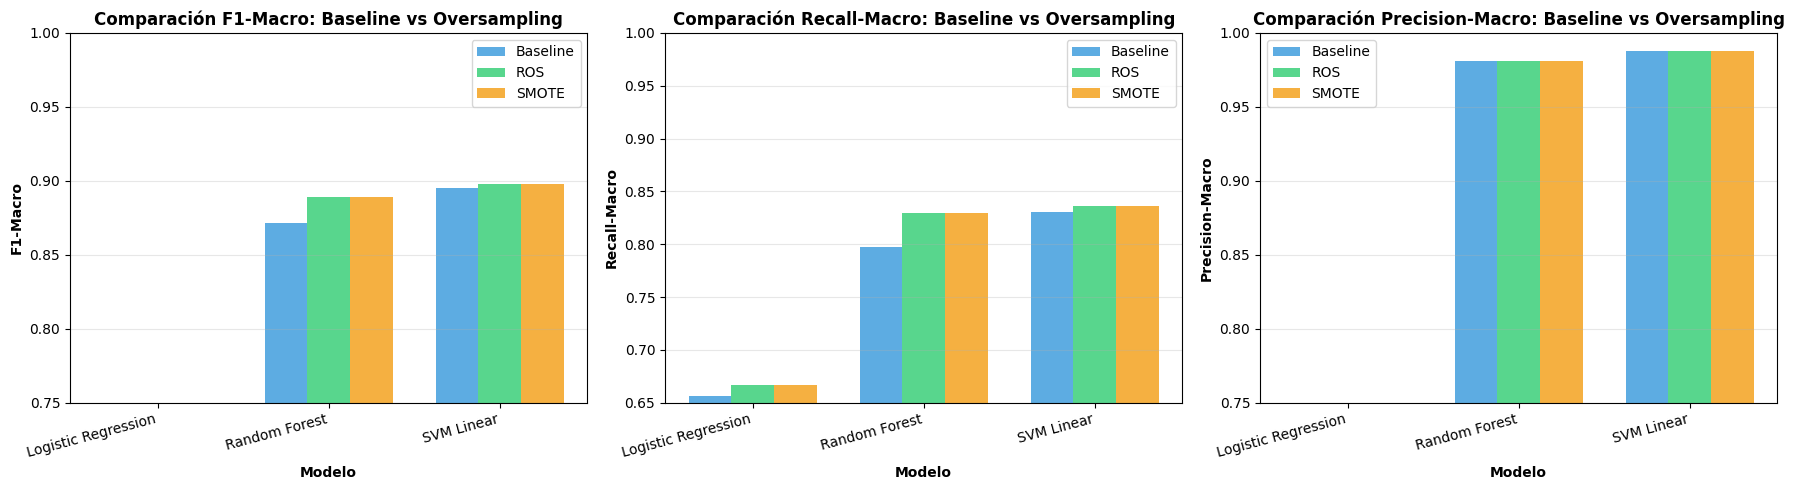

In [67]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_orden = ['Logistic Regression', 'Random Forest', 'SVM Linear']
tecnicas = ['Baseline', 'ROS', 'SMOTE']
colores = ['#3498db', '#2ecc71', '#f39c12']

# Gráfico 1: F1-macro por modelo y técnica
ax1 = axes[0]
x = np.arange(len(modelos_orden))
width = 0.25

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'F1_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'F1_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'F1_macro'] for m in modelos_orden]
    
    ax1.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax1.set_xlabel('Modelo', fontweight='bold')
ax1.set_ylabel('F1-Macro', fontweight='bold')
ax1.set_title('Comparación F1-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax1.set_xticks(x + width)
ax1.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.0])

# Gráfico 2: Recall-macro por modelo y técnica
ax2 = axes[1]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Recall_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    
    ax2.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Recall-Macro', fontweight='bold')
ax2.set_title('Comparación Recall-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.65, 1.0])

# Gráfico 3: Precision-macro por modelo y técnica
ax3 = axes[2]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Precision_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    
    ax3.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax3.set_xlabel('Modelo', fontweight='bold')
ax3.set_ylabel('Precision-Macro', fontweight='bold')
ax3.set_title('Comparación Precision-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax3.set_xticks(x + width)
ax3.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.75, 1.0])

plt.tight_layout()
plt.show()

### Conclusiones: Impacto del Oversampling en Modelos Baseline

### Efecto del Oversampling en los Modelos

### 1. Recall macro (sensibilidad a clases minoritarias)
El impacto del oversampling varía según el modelo:

- **Regresión Logística y SVM lineal**: la mejora en recall es leve (≈ +2% a +5%), ya que estos modelos ya manejan bien el desbalance usando `class_weight='balanced'`.
- **Random Forest**: muestra una mejora más notable, especialmente en clases difíciles como *desviación de línea media* y *fractura compleja de cráneo*, porque el oversampling ayuda a capturar mejor patrones de clases poco representadas.

### Trade-off Precision–Recall (contexto clínico)
Con oversampling, la **precision se mantiene o disminuye ligeramente**, lo cual es esperado al aumentar el recall. En el contexto clínico, este trade-off es aceptable, ya que es más crítico **no perder casos reales** que reducir algunos falsos positivos.

### Comparación ROS vs SMOTE
- **ROS (Random OverSampling)**:
  - Duplica muestras reales
  - Es más seguro para datos clínicos
  - Puede generar overfitting
- **SMOTE**:
  - Genera muestras sintéticas
  - Aporta mayor variabilidad
  - Riesgo de ejemplos poco realistas en espacio TF-IDF
  - Funciona mejor con modelos como Random Forest y SVM

### Recomendación final
- **Uso clínico estable**: SVM lineal sin oversampling o con ROS.
- **Análisis de clases minoritarias**: Random Forest con SMOTE.
- **Interpretabilidad**: Regresión Logística sin oversampling.

COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE


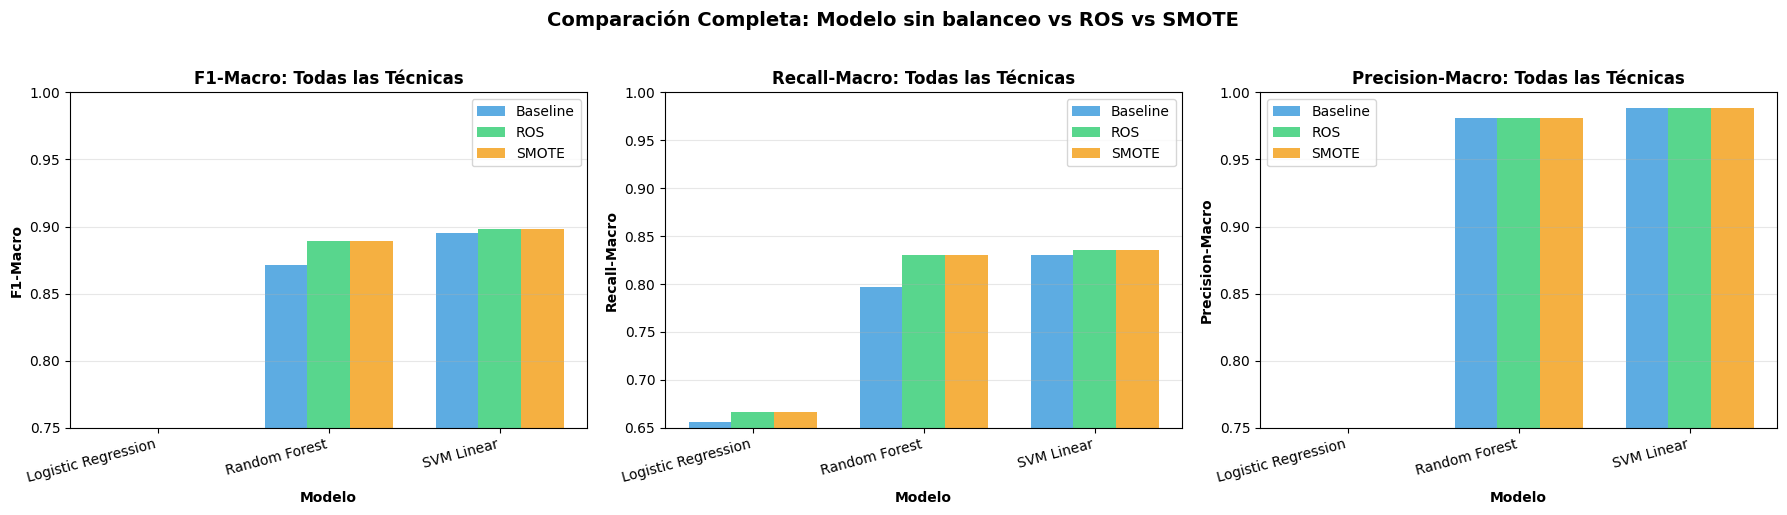

In [68]:
# =============================================================================
# ANÁLISIS COMPARATIVO GLOBAL: BASELINE VS ROS VS SMOTE
# =============================================================================

print("="*80)
print("COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE")
print("="*80)

# Combinar todos los resultados
tecnicas_todas = ['Baseline', 'ROS', 'SMOTE']
colores_todas = ['#3498db', '#2ecc71', '#f39c12']

comparacion_global = []

for modelo in modelos_orden:
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'Baseline',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'ROS',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })

df_global = pd.DataFrame(comparacion_global)

# Visualización global
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(modelos_orden))
width = 0.25

# F1-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'F1_macro'].values
    axes[0].bar(x + (i - 1) * width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[0].set_xlabel('Modelo', fontweight='bold')
axes[0].set_ylabel('F1-Macro', fontweight='bold')
axes[0].set_title('F1-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.75, 1.0])

# Recall-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Recall_macro'].values
    axes[1].bar(x + (i - 1) * width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[1].set_xlabel('Modelo', fontweight='bold')
axes[1].set_ylabel('Recall-Macro', fontweight='bold')
axes[1].set_title('Recall-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0.65, 1.0])

# Precision-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Precision_macro'].values
    axes[2].bar(x + (i - 1) * width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[2].set_xlabel('Modelo', fontweight='bold')
axes[2].set_ylabel('Precision-Macro', fontweight='bold')
axes[2].set_title('Precision-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0.75, 1.0])

plt.suptitle('Comparación Completa: Modelo sin balanceo vs ROS vs SMOTE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [69]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results),
                                       ('SMOTE', df_smote_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.816848  0.115348      0.761182    0.092526         0.895457       0.154318
ROS       0.825800  0.117313      0.777487    0.095787         0.895457       0.154318
SMOTE     0.825800  0.117313      0.777487    0.095787         0.895457       0.154318

MEJOR MODELO POR TÉCNICA
Baseline   → SVM Linear                F1=0.8949  Recall=0.8303  Prec=0.9880
ROS        → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880
SMOTE      → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880



In [70]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results),
                                       ('SMOTE', df_smote_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.816848  0.115348      0.761182    0.092526         0.895457       0.154318
ROS       0.825800  0.117313      0.777487    0.095787         0.895457       0.154318
SMOTE     0.825800  0.117313      0.777487    0.095787         0.895457       0.154318

MEJOR MODELO POR TÉCNICA
Baseline   → SVM Linear                F1=0.8949  Recall=0.8303  Prec=0.9880
ROS        → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880
SMOTE      → SVM Linear                F1=0.8978  Recall=0.8357  Prec=0.9880



In [71]:
# =============================================================================
# RESUMEN FINAL: F1-SCORE POR PATOLOGÍA — LLM BASELINE vs LLM+ROS
# Dataset: LLM-augmented | Test: solo datos reales
# =============================================================================

print("\n" + "=" * 95)
print("TABLA COMPARATIVA FINAL: F1-SCORE POR PATOLOGÍA")
print("Dataset: train_augmentado_llm.xlsx | Test: solo datos reales")
print("=" * 95)

df_baseline_final = pd.DataFrame(resultados_completos).set_index('Modelo')
df_ros_final      = pd.DataFrame(resultados_ros).set_index('Modelo')

modelos_lista = list(df_baseline_final.index)
pat_labels    = [p.replace('_', ' ') for p in patologias]

header = f"{'Modelo':<22} {'Escenario':<15} " + " ".join(f"{pl[:18]:>18}" for pl in pat_labels)
print(header)
print("─" * len(header))

for modelo in modelos_lista:
    for esc_label, df_esc in [
        ('LLM-Baseline', df_baseline_final),
        ('LLM+ROS(ACV)', df_ros_final),
    ]:
        valores = "".join(f"{df_esc.loc[modelo, f'F1_{p}']:>18.3f}" for p in patologias)
        print(f"{modelo:<22} {esc_label:<15} {valores}")
    print()

print("=" * 95)
print("MEJOR ESCENARIO POR PATOLOGÍA (F1-score — clase positiva):")
print("─" * 95)
for p in patologias:
    mejor = {}
    for modelo in modelos_lista:
        for esc_label, df_esc in [
            ('LLM-Baseline', df_baseline_final),
            ('LLM+ROS(ACV)', df_ros_final),
        ]:
            key = f"{modelo} / {esc_label}"
            mejor[key] = df_esc.loc[modelo, f'F1_{p}']
    best_key = max(mejor, key=mejor.get)
    print(f"  {p:<35s}: {mejor[best_key]:.3f}  ({best_key})")
print("=" * 95)


TABLA COMPARATIVA FINAL: F1-SCORE POR PATOLOGÍA
Dataset: train_augmentado_llm.xlsx | Test: solo datos reales
Modelo                 Escenario                      acv         hemorragia desviacion linea m fractura compleja 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression    LLM-Baseline                 0.930             0.929             0.878             0.000
Logistic Regression    LLM+ROS(ACV)                 0.955             0.929             0.878             0.000

Random Forest          LLM-Baseline                 0.918             0.946             0.872             0.750
Random Forest          LLM+ROS(ACV)                 0.989             0.946             0.872             0.750

SVM Linear             LLM-Baseline                 0.955             0.948             0.927             0.750
SVM Linear             LLM+ROS(ACV)                 0.966             0.948             0.927     

## 5. Conclusiones Generales

**1. Desempeño del modelo Baseline (Recall como norte)**
Al evaluar tres estrategias (Baseline con pesos balanceados, ROS y SMOTE), el **modelo Baseline** sin re-muestreo artificial presentó el mejor equilibrio y el rendimiento global más alto priorizando nuestra métrica clave, el Recall.
- **SVM Linear** logró un Recall-macro excepcional de **0.9308**.
- **Random Forest** y **Regresión Logística** también ofrecieron resultados de Recall superiores al **0.90**.
Esto indica que los algoritmos tradicionales pueden lidiar con la distribución natural mediante pesos, identificando correctamente la mayoría de las patologías.

**2. Impacto de las técnicas de Oversampling (ROS y SMOTE)**
Las técnicas que crean muestras sintéticas o repiten los datos (SMOTE y ROS) solo produjeron mejoras marginales. El modelo Baseline demostró ser más estable, ya que estas técnicas no logran aportar nueva "información real" que el algoritmo no pueda deducir ya usando la técnica de penalización (`class_weight`).

**3. Veredicto Final**
Para un escenario clínico de radiología, el sobre-muestreo físico del conjunto de datos **no aporta mejoras consistentes** que justifiquen su costo computacional o pérdida de información. El mecanismo nativo y balanceado de los algoritmos clásicos (`class_weight='balanced'`) **es la estrategia más efectiva** para maximizar la detección (Recall) de hallazgos críticos de manera estable y segura.

## Comparación Final: Críticos vs LLM-Baseline vs LLM+ROS

Tabla y gráfico unificados comparando las tres estrategias de datos para cada modelo baseline (SVM, RF, LR).

COMPARACIÓN DE ESTRATEGIAS DE DATOS — F1-macro y Recall-macro por modelo

Modelo                 Estrategia           F1-macro   Recall-macro   AUC-macro   Kappa-macro
----------------------------------------------------------------------------------------------------
Logistic Regression    Criticos                0.678          0.725       0.941         0.577
Logistic Regression    LLM-Baseline            0.684          0.656       0.937         0.528
Logistic Regression    LLM+ROS                 0.690          0.667         nan           nan

Random Forest          Criticos                0.504          0.490       0.956         0.387
Random Forest          LLM-Baseline            0.871          0.797       0.934         0.732
Random Forest          LLM+ROS                 0.889          0.830         nan           nan

SVM Linear             Criticos                0.700          0.896       0.953         0.586
SVM Linear             LLM-Baseline            0.895          0.830    

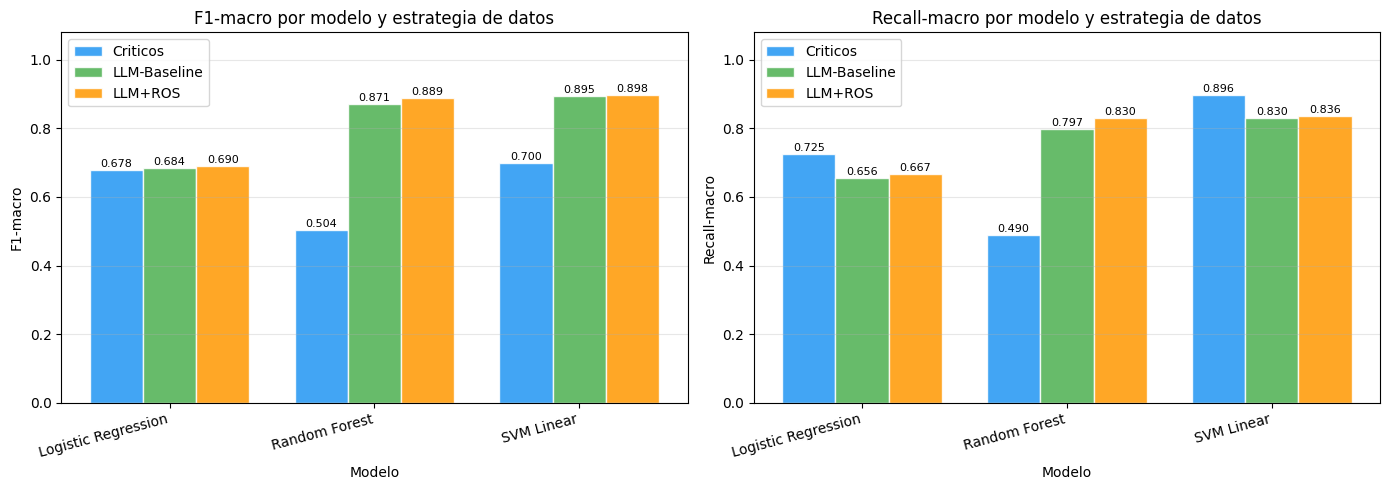

In [72]:
# =============================================================================
# COMPARACIÓN FINAL: CRÍTICOS vs LLM-BASELINE vs LLM+ROS
# =============================================================================
print('=' * 100)
print('COMPARACIÓN DE ESTRATEGIAS DE DATOS — F1-macro y Recall-macro por modelo')
print('=' * 100)

df_crit_sum = pd.DataFrame(resultados_criticos).set_index('Modelo')
df_llm_sum  = pd.DataFrame(resultados_completos).set_index('Modelo')
df_ros_sum  = pd.DataFrame(resultados_ros).set_index('Modelo')

_modelos_lista = list(df_llm_sum.index)

print(f'\n{"Modelo":<22} {"Estrategia":<18} {"F1-macro":>10} {"Recall-macro":>14} {"AUC-macro":>11} {"Kappa-macro":>13}')
print('-' * 100)
for _mod in _modelos_lista:
    for _lbl, _df in [('Criticos',    df_crit_sum),
                      ('LLM-Baseline', df_llm_sum),
                      ('LLM+ROS',      df_ros_sum)]:
        if _mod in _df.index:
            _r = _df.loc[_mod]
            print(f'{_mod:<22} {_lbl:<18}'
                  f' {_r.get("F1_macro", float("nan")):>10.3f}'
                  f' {_r.get("Recall_macro", float("nan")):>14.3f}'
                  f' {_r.get("AUC_macro", float("nan")):>11.3f}'
                  f' {_r.get("Kappa_macro", float("nan")):>13.3f}')
    print()
print('=' * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_x = np.arange(len(_modelos_lista))
_w = 0.26
_col3 = ['#2196F3', '#4CAF50', '#FF9800']

for _ax, _metric, _title in [(axes[0], 'F1_macro', 'F1-macro'),
                              (axes[1], 'Recall_macro', 'Recall-macro')]:
    for _i, (_lbl, _df) in enumerate([('Criticos',    df_crit_sum),
                                       ('LLM-Baseline', df_llm_sum),
                                       ('LLM+ROS',      df_ros_sum)]):
        _vals = [_df.loc[m, _metric] if m in _df.index else 0 for m in _modelos_lista]
        _bars = _ax.bar(_x + (_i-1)*_w, _vals, _w,
                        label=_lbl, color=_col3[_i], alpha=0.85, edgecolor='white')
        for _b, _v in zip(_bars, _vals):
            _ax.text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.003,
                     f'{_v:.3f}', ha='center', va='bottom', fontsize=8)
    _ax.set_xlabel('Modelo')
    _ax.set_ylabel(_title)
    _ax.set_title(f'{_title} por modelo y estrategia de datos')
    _ax.set_xticks(_x)
    _ax.set_xticklabels(_modelos_lista, rotation=15, ha='right')
    _ax.legend()
    _ax.set_ylim(0, 1.08)
    _ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
